# Purpose

Calculate NPS concentration needed for a 25 &mu;m penetration depth for Roman Voronov to use with 20 &mu;m thick layers and a 385 nm LED in an Asiga Pro 4k with native pixel size of 65 &mu;m.

# Imports

In [1]:
from pathlib import Path
import typing

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib
#%matplotlib widget
%matplotlib inline

from scipy.optimize import curve_fit
import scipy.integrate as integrate

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.sourcespectrum import SourceSpectrum
from spectra.utilities import ArrayParams
from spectra.irradiance import Irradiance
from spectra.normalizeddose import NormalizedDose

In [2]:
import sys
!{sys.executable} --version

Python 3.12.2


# Available spectrum data

In [3]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e210>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e2d0>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e360>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x14a2564b0>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e300>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e450>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e4b0>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e510>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e570>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x14a27e5d

In [4]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27cda0>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a0c0b00>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a013590>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27cf50>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27d040>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27d070>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27d280>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27d250>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x11aa81280>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x14a27d520>,
 'sudanI_in_PEGDA_2017-04-13': <spectra.absorberspectru

In [5]:
data.monomers

{'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/hdda.json),
 'Ideal': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/ideal.json),
 'PEGDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/pegda.json),
 'TET': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/tet.json)}

## Which 385 nm source to use?

In [6]:
source_385nm_a = data.sources['HR2_385nm_2020-03-23']
source_385nm_b = data.sources['MR1_385nm_Visitech-2020-03-25']

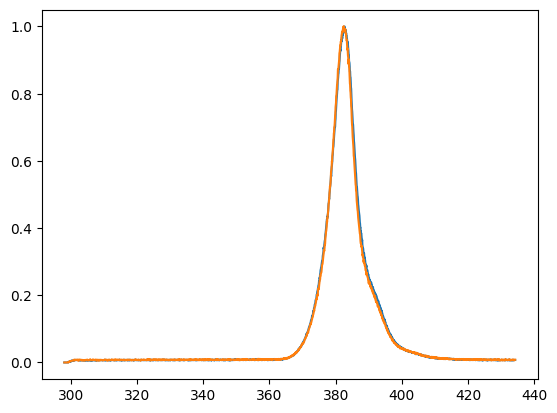

In [7]:
fig, ax = plt.subplots()
ax.plot(source_385nm_a.wavelength, source_385nm_a.power)
ax.plot(source_385nm_b.wavelength, source_385nm_b.power)


### Conclusion: they are the same

# Initialize parameters

## Resins

In [8]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
nps_2p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)
nps_1p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.0
)
nps_0p5 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    0.5
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin_nps2p0 = Resin(monomers=pegda, absorbers=nps_2p0, photoinitiators=irgacure819)
resin_nps1p0 = Resin(monomers=pegda, absorbers=nps_1p0, photoinitiators=irgacure819)
resin_nps0p5 = Resin(monomers=pegda, absorbers=nps_0p5, photoinitiators=irgacure819)
print(f"{resin_nps2p0.name=}")
print(f"{resin_nps1p0.name=}")

resin_nps2p0.name='PEG-100__NPS-2__Irg-1'
resin_nps1p0.name='PEG-100__NPS-1__Irg-1'


## 385 nm LED

In [9]:
source = data.sources['MR1_385nm_Visitech-2020-03-25']

## Wavelength sampling array parameters

In [10]:
wavelength_array_parameters = ArrayParams(300, 440, 401)

# Calculations

In [11]:
irradiance_nps2p0 = Irradiance(source=source, resin=resin_nps2p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps1p0 = Irradiance(source=source, resin=resin_nps1p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps0p5 = Irradiance(source=source, resin=resin_nps0p5, wavelength_array_params=wavelength_array_parameters)

PEG-100__NPS-2__Irg-1


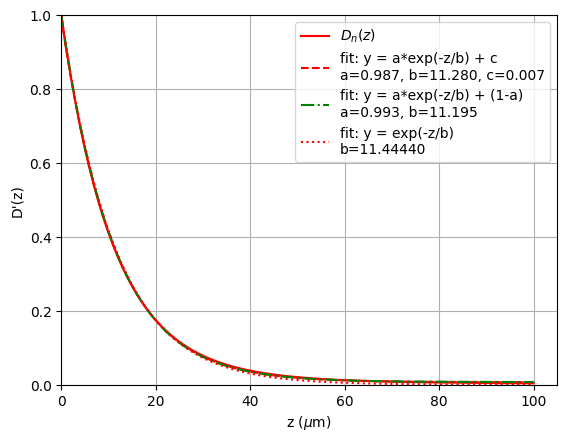

In [12]:
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose_nps2p0 = NormalizedDose(irradiance=irradiance_nps2p0, z_array_params=z_array_params)
print(norm_dose_nps2p0.irradiance.resin.name)
norm_dose_nps2p0.plot();

PEG-100__NPS-1__Irg-1


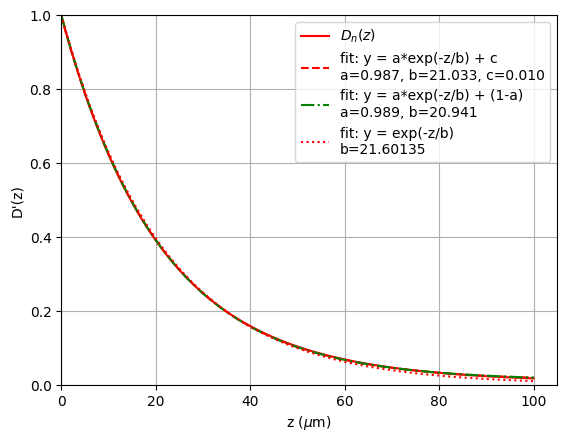

In [13]:
# Normalized dose
norm_dose_nps1p0 = NormalizedDose(irradiance=irradiance_nps1p0, z_array_params=z_array_params)
print(norm_dose_nps1p0.irradiance.resin.name)
norm_dose_nps1p0.plot();

PEG-100__NPS-0.5__Irg-1


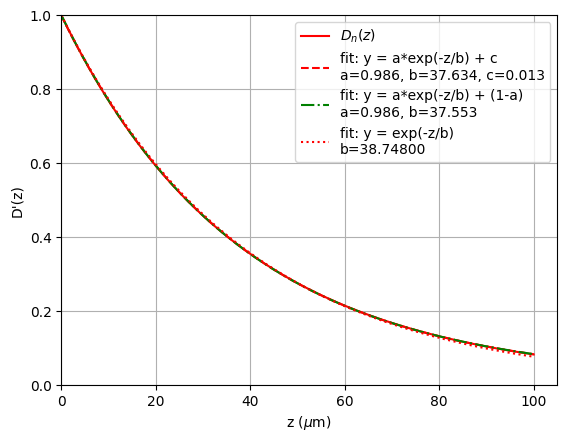

In [14]:
# Normalized dose
norm_dose_nps0p5 = NormalizedDose(irradiance=irradiance_nps0p5, z_array_params=z_array_params)
print(norm_dose_nps0p5.irradiance.resin.name)
norm_dose_nps0p5.plot();

In [46]:
dir(norm_dose_nps2p0)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_calc_normalized_dose',
 '_fit_to_a_b_c_model',
 '_fit_to_a_b_model',
 '_fit_to_ha_model',
 'a_b_c_model',
 'a_b_c_model_params',
 'a_b_model',
 'a_b_model_params',
 'ha_model',
 'ha_model_params',
 'irradiance',
 'normalized_dose',
 'plot',
 'source_integral',
 'z_array_params',
 'z_um']

In [47]:
norm_dose_nps2p0.a_b_model_params

{'a': 0.9927904182576006,
 'b': 11.194593349303492,
 'stdev': array([0.0002223, 0.0136884])}

# Penetration depth vs NPS concentration

In [35]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

nps_conc_values = np.linspace(0.5, 2.0, num=16)
optical_penetration_depth = []

for nps_conc in nps_conc_values:
    absorber = ResinConstituentAbsorber(
        data.absorbers['nps_in_PEGDA_2017-04-13'],
        nps_conc
    )
    resin = Resin(monomers=pegda, absorbers=absorber, photoinitiators=irgacure819)
    irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)
    norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)
    optical_penetration_depth.append(norm_dose.a_b_model_params['b'])
    

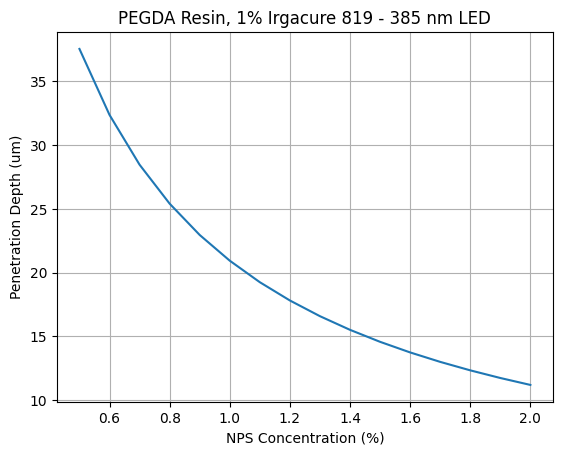

In [48]:
fig, ax = plt.subplots()
ax.plot(nps_conc_values, optical_penetration_depth)
ax.set_xlabel("NPS Concentration (%)")
ax.set_ylabel("Penetration Depth (um)")
ax.set_title("PEGDA Resin, 1% Irgacure 819 - 385 nm LED")
ax.grid()
plt.savefig("h_a_vs_NPS_concentration.png")

In [44]:
print("NPS conc. (%) | Optical penetration depth (um)")
print("----------------------------------------------")
for conc, h_a in zip(nps_conc_values, optical_penetration_depth):
    print(f"      {conc:0.2f}    |      {h_a:.2f}")

NPS conc. (%) | Optical penetration depth (um)
----------------------------------------------
      0.50    |      37.55
      0.60    |      32.38
      0.70    |      28.47
      0.80    |      25.41
      0.90    |      22.96
      1.00    |      20.94
      1.10    |      19.25
      1.20    |      17.82
      1.30    |      16.59
      1.40    |      15.52
      1.50    |      14.58
      1.60    |      13.74
      1.70    |      13.00
      1.80    |      12.34
      1.90    |      11.74
      2.00    |      11.19
